# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [1]:
# Import warnings
import warnings



In [2]:
# pip install numpy==1.26.4
# pip install pandas==2.2.2
# pip install matplotlin==3.10.0
# pip install seaborn==0.13.2

In [3]:
# Import the libraries you will be using for analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 1.26.4
pandas version: 2.2.2
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [7]:
# Try loading one file

# df = pd.read_parquet('2023-1.parquet')
# df.info()
df=pd.read_parquet('../Datasets and Dictionary/trip_records/2023-1.parquet')
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00


How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [6]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [7]:
# from google.colab import drive
# drive.mount('/content/drive')

In [20]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os

# Select the folder having data files
os.chdir('../Datasets and Dictionary/trip_records')



# Create a list of all the twelve files to read
file_list = os.listdir()

# initialise an empty dataframe
df = pd.DataFrame()


# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)

        # Reading the current file
        readCurrentFileDf=pd.read_parquet(file_path)

        # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
        # After completing iteration through each date, we will append this data to the final dataframe.
        sampled_data = pd.DataFrame()
        #selecting only 2023 data as data has 2008 and 2022 enteries as well
        filteredDf=readCurrentFileDf[ readCurrentFileDf["tpep_pickup_datetime"].dt.year==2023]
        dates=filteredDf["tpep_pickup_datetime"].dt.date.unique()
        sortedDates=sorted(dates)

        # Loop through dates and then loop through every hour of each date
        for date in sortedDates:
            dailyData= filteredDf[filteredDf["tpep_pickup_datetime"].dt.date==date]
            hours=dailyData["tpep_pickup_datetime"].dt.hour.unique()
            sortedHours=sorted(hours)
            
            # Iterate through each hour of the selected date
            for hour in sortedHours:
                hourly_data=dailyData[dailyData["tpep_pickup_datetime"].dt.hour==hour]

                # Sample 5% of the hourly data randomly
                sample=hourly_data.sample(frac=0.0078,random_state=42)# Only sampling 0.78% of the data to keep the records 250000 to 300000

                # add data of this hour to the dataframe
                sampled_data=pd.concat([sampled_data,sample])
        
        # Concatenate the sampled data of all the dates to a single dataframe
        df = pd.concat([df,sampled_data])# we initialised this empty DF earlier

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

In [8]:
len(df)
df.shape

(3041714, 19)

After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [9]:
# Store the df in csv/parquet
# df.to_parquet('')
df.to_parquet('Sampled2023TripRecords.parquet')

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [9]:
# Load the new data file
df=pd.read_parquet('Sampled2023TripRecords.parquet')


In [11]:
# df.head()
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee
428,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,32.40,6.0,0.5,0.00,0.0,1.0,41.15,0.0,1.25,NaN
1113,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,7.90,1.0,0.5,2.58,0.0,1.0,15.48,2.5,0.00,NaN
819,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,11.40,1.0,0.5,0.00,0.0,1.0,16.40,2.5,0.00,NaN
3192,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,6.50,1.0,0.5,0.00,0.0,1.0,11.50,2.5,0.00,NaN
2995263,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,None,66,107,0,25.64,0.0,0.5,5.93,0.0,1.0,35.57,NaN,NaN,NaN


In [13]:
# df.info()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 295849 entries, 428 to 2702225
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               295849 non-null  int64         
 1   tpep_pickup_datetime   295849 non-null  datetime64[us]
 2   tpep_dropoff_datetime  295849 non-null  datetime64[us]
 3   passenger_count        285930 non-null  float64       
 4   trip_distance          295849 non-null  float64       
 5   RatecodeID             285930 non-null  float64       
 6   store_and_fwd_flag     285930 non-null  object        
 7   PULocationID           295849 non-null  int64         
 8   DOLocationID           295849 non-null  int64         
 9   payment_type           295849 non-null  int64         
 10  fare_amount            295849 non-null  float64       
 11  extra                  295849 non-null  float64       
 12  mta_tax                295849 non-null  float6

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [15]:
# Fix the index and drop any columns that are not needed
df["month"]=df["tpep_pickup_datetime"].dt.month
df=df.sort_values("month").reset_index(drop=True)
df.drop(["month","store_and_fwd_flag"],axis=1,inplace=True)


**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [17]:
# Combine the two airport fee columns
df['combined_airport_fee']= df['airport_fee'].combine_first(df['Airport_fee'])

In [19]:
# Checking if there is any row in which both the column has value
df[ ~df['airport_fee'].isnull() & ~df['Airport_fee'].isnull()]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee,combined_airport_fee


In [21]:
df.drop(['airport_fee','Airport_fee'],axis=1,inplace=True)


In [23]:
df=df.rename(columns={'combined_airport_fee':'airport_fee'})
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,138,256,2,32.4,6.0,0.5,0.00,0.0,1.0,41.15,0.0,1.25
1,2,2023-01-21 21:39:38,2023-01-21 21:56:27,1.0,1.42,1.0,113,148,1,14.9,1.0,0.5,2.98,0.0,1.0,22.88,2.5,0.00
2,2,2023-01-21 21:32:31,2023-01-21 21:43:23,2.0,2.31,1.0,237,238,1,13.5,1.0,0.5,2.50,0.0,1.0,21.00,2.5,0.00
3,2,2023-01-21 21:36:00,2023-01-21 21:46:25,1.0,1.37,1.0,113,246,1,11.4,1.0,0.5,2.95,0.0,1.0,19.35,2.5,0.00
4,2,2023-01-21 21:47:14,2023-01-21 21:55:09,3.0,1.42,1.0,261,125,1,10.0,1.0,0.5,3.00,0.0,1.0,18.00,2.5,0.00


**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [25]:
# check where values of fare amount are negative
df[df["fare_amount"]<0]



,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee


Did you notice something different in the `RatecodeID` column for above records?

In [27]:
# Analyse RatecodeID for the negative fare amounts
df[df["fare_amount"]<0] # There seems to be no records with negative fare amount



,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee


In [29]:
# Find which columns have negative values
num_cols = df.select_dtypes(include='number').columns
negative_vals = df[num_cols] < 0
negative_counts=negative_vals.sum()
print("Columns with negative value",negative_counts[negative_counts>0])



Columns with negative value extra                     1
mta_tax                  11
improvement_surcharge    11
total_amount             11
congestion_surcharge      6
airport_fee               2
dtype: int64


In [31]:
# fix these negative values
# Fixing mta_tax as this tax cannot be in negative
df=df[~(df["mta_tax"]<0)]



In [33]:
#after removing mta_tax negative records checking for any other column with negative value
num_cols = df.select_dtypes(include='number').columns
negative_vals = df[num_cols] < 0
negative_counts=negative_vals.sum()
print("Columns with negative value",negative_counts[negative_counts>0])

Columns with negative value extra    1
dtype: int64


In [35]:
df[df["extra"]<0]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
242575,2,2023-10-27 14:51:03,2023-10-27 14:51:11,1.0,0.0,1.0,265,265,2,3.0,-2.5,0.0,0.0,0.0,1.0,4.0,0.0,0.0


In [37]:
# As the trip distance is 0 and pick up , droptime is almost same therefre removing this record
df=df[~(df["extra"]<0)]

### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [39]:
# Find the proportion of missing values in each column
df.isnull().mean(axis=0)*100



VendorID                 0.00000
tpep_pickup_datetime     0.00000
tpep_dropoff_datetime    0.00000
passenger_count          3.35286
trip_distance            0.00000
RatecodeID               3.35286
PULocationID             0.00000
DOLocationID             0.00000
payment_type             0.00000
fare_amount              0.00000
extra                    0.00000
mta_tax                  0.00000
tip_amount               0.00000
tolls_amount             0.00000
improvement_surcharge    0.00000
total_amount             0.00000
congestion_surcharge     3.35286
airport_fee              3.35286
dtype: float64

**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [41]:
# Display the rows with null values
print(df[df['passenger_count'].isnull()].head())
# Impute NaN values in 'passenger_count'
df['passenger_count'].value_counts(normalize=True) # getting the value_counts for passenger_count
df['passenger_count'].mode() # checking the mode of passenger_count
df.loc[df['passenger_count'].isnull(),'passenger_count']=1


     VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
63          1  2023-01-21 19:58:01   2023-01-21 20:10:10              NaN   
91          1  2023-01-21 21:20:31   2023-01-21 21:25:15              NaN   
155         1  2023-01-21 21:29:24   2023-01-21 21:35:22              NaN   
168         2  2023-01-21 22:16:00   2023-01-21 22:39:00              NaN   
186         1  2023-01-21 17:02:15   2023-01-21 17:29:29              NaN   

     trip_distance  RatecodeID  PULocationID  DOLocationID  payment_type  \
63            1.20         NaN           161            50             0   
91            1.00         NaN           163           264             0   
155           0.00         NaN           231            13             0   
168           3.91         NaN           186           231             0   
186           3.70         NaN           263            79             0   

     fare_amount  extra  mta_tax  tip_amount  tolls_amount  \
63         11.40  

Did you find zeroes in passenger_count? Handle these.

In [43]:
df[df['passenger_count']==0]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
85,1,2023-01-21 20:32:32,2023-01-21 20:39:26,0.0,1.0,1.0,142,239,1,7.2,3.5,0.5,2.40,0.0,1.0,14.60,2.5,0.0
288,1,2023-01-21 19:37:01,2023-01-21 19:41:49,0.0,0.9,1.0,237,140,2,7.2,2.5,0.5,0.00,0.0,1.0,11.20,2.5,0.0
309,1,2023-01-21 19:05:23,2023-01-21 19:11:09,0.0,1.7,1.0,239,166,1,8.6,2.5,0.5,3.10,0.0,1.0,15.70,2.5,0.0
380,1,2023-01-22 11:13:09,2023-01-22 11:20:18,0.0,1.4,1.0,141,239,2,9.3,2.5,0.5,0.00,0.0,1.0,13.30,2.5,0.0
404,1,2023-01-22 11:50:58,2023-01-22 12:01:44,0.0,1.6,1.0,90,158,1,12.1,2.5,0.5,3.22,0.0,1.0,19.32,2.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295300,1,2023-12-09 16:06:26,2023-12-09 16:13:06,0.0,1.0,1.0,142,143,1,8.6,2.5,0.5,2.50,0.0,1.0,15.10,2.5,0.0
295400,1,2023-12-09 18:04:35,2023-12-09 18:34:19,0.0,3.8,1.0,239,68,1,23.3,2.5,0.5,3.00,0.0,1.0,30.30,2.5,0.0
295452,1,2023-12-10 08:16:33,2023-12-10 08:22:22,0.0,1.2,1.0,48,43,2,7.9,2.5,0.5,0.00,0.0,1.0,11.90,2.5,0.0
295760,1,2023-12-10 02:37:18,2023-12-10 02:44:02,0.0,0.7,1.0,144,211,1,7.2,3.5,0.5,3.00,0.0,1.0,15.20,2.5,0.0


In [45]:
df[(df['passenger_count']==0) & (df['fare_amount']==0)]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
14043,1,2023-01-09 09:25:20,2023-01-09 09:26:01,0.0,0.0,1.0,145,145,2,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00
35320,1,2023-02-24 14:22:52,2023-02-24 14:26:24,0.0,0.2,1.0,161,162,4,0.0,0.0,0.0,0.0,0.0,1.0,1.00,0.0,0.00
57005,1,2023-03-30 23:20:54,2023-03-30 23:21:12,0.0,0.1,5.0,265,265,2,0.0,0.0,0.0,0.0,0.0,1.0,1.00,0.0,0.00
142654,2,2023-06-02 01:58:22,2023-06-02 01:58:34,0.0,0.0,5.0,132,132,2,0.0,0.0,0.5,0.0,0.0,1.0,3.25,0.0,1.75


In [47]:
#Removing the Above Data points as passenger_count is 0 and fare_amount is 0  means these can be some incorrect enteries
df= df[~((df['passenger_count']==0) & (df['fare_amount']==0))]

In [49]:
# Imputing the mode value for passenger count wherever it is 0
df.loc[df['passenger_count']==0,['passenger_count']]=1

In [51]:
df["passenger_count"].value_counts()

passenger_count
1.0    229964
2.0     42995
3.0     10770
4.0      5924
5.0      3668
6.0      2507
7.0         2
8.0         2
9.0         1
Name: count, dtype: int64

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [53]:
# Fix missing values in 'RatecodeID'
df.isnull().sum(axis=0)


VendorID                    0
tpep_pickup_datetime        0
tpep_dropoff_datetime       0
passenger_count             0
trip_distance               0
RatecodeID               9919
PULocationID                0
DOLocationID                0
payment_type                0
fare_amount                 0
extra                       0
mta_tax                     0
tip_amount                  0
tolls_amount                0
improvement_surcharge       0
total_amount                0
congestion_surcharge     9919
airport_fee              9919
dtype: int64

In [55]:
mode=df['RatecodeID'].mode()[0]

In [57]:
df.loc[df['RatecodeID'].isnull(),['RatecodeID']]=mode

**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [59]:
# handle null values in congestion_surcharge
median=df['congestion_surcharge'].median() # Selecting the median for imputing congestion surcharge

df.loc[df['congestion_surcharge'].isnull(),['congestion_surcharge']]=median

In [61]:
df.isnull().sum(axis=0)

VendorID                    0
tpep_pickup_datetime        0
tpep_dropoff_datetime       0
passenger_count             0
trip_distance               0
RatecodeID                  0
PULocationID                0
DOLocationID                0
payment_type                0
fare_amount                 0
extra                       0
mta_tax                     0
tip_amount                  0
tolls_amount                0
improvement_surcharge       0
total_amount                0
congestion_surcharge        0
airport_fee              9919
dtype: int64

Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [63]:
df['airport_fee'].value_counts()

airport_fee
0.00    260839
1.75     18773
1.25      6302
Name: count, dtype: int64

In [65]:
# Handle any remaining missing values
airportFeeMedian=df['airport_fee'].median()
df.loc[df['airport_fee'].isnull(),['airport_fee']]=airportFeeMedian



In [67]:
df['airport_fee'].value_counts()

airport_fee
0.00    270758
1.75     18773
1.25      6302
Name: count, dtype: int64

In [69]:
df.isnull().sum(axis=0)

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
airport_fee              0
dtype: int64

### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [71]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns
df.describe()



,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
count,295833.000000,295833,295833,295833.000000,295833.000000,295833.000000,295833.000000,295833.000000,295833.000000,295833.000000,295833.000000,295833.000000,295833.00000,295833.000000,295833.000000,295833.000000,295833.000000,295833.000000
mean,1.733688,2023-07-02 19:45:51.238124,2023-07-02 20:03:11.220276,1.370304,3.564424,1.631498,165.239987,163.916919,1.164637,20.303812,1.586157,0.495386,3.54543,0.591795,0.999068,29.359901,2.315166,0.137680
min,1.000000,2023-01-01 00:04:34,2023-01-01 00:09:40,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,2023-04-02 16:03:02,2023-04-02 16:18:03,1.000000,1.050000,1.000000,132.000000,113.000000,1.000000,9.300000,0.000000,0.500000,1.00000,0.000000,1.000000,15.960000,2.500000,0.000000
50%,2.000000,2023-06-27 15:27:51,2023-06-27 15:46:55,1.000000,1.800000,1.000000,162.000000,162.000000,1.000000,13.500000,1.000000,0.500000,2.84000,0.000000,1.000000,21.000000,2.500000,0.000000
75%,2.000000,2023-10-06 19:31:29,2023-10-06 19:42:19,1.000000,3.400000,1.000000,234.000000,234.000000,1.000000,21.900000,2.500000,0.500000,4.42000,0.000000,1.000000,30.800000,2.500000,0.000000
max,6.000000,2023-12-31 23:54:03,2024-01-01 20:14:57,9.000000,22528.820000,99.000000,265.000000,265.000000,4.000000,143163.450000,14.250000,0.800000,150.29000,143.000000,1.000000,143167.450000,2.500000,1.750000
std,0.447578,NaN,NaN,0.863187,46.058381,7.390577,64.051063,69.792534,0.506843,263.805306,1.823734,0.047885,4.05034,2.173077,0.028046,264.149110,0.654158,0.456805


**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [73]:
# remove passenger_count > 6
df=df[~(df['passenger_count']>6)]


In [75]:
# Continue with outlier handling
df=df[~((df["trip_distance"]==0) & (df['fare_amount']>=300))] # Removing enteries where trip distance is near 0 and fare amount is greater than equal to 300



In [77]:
# Removing the rows where trip_distance and fare_amount is 0 but the drop and pickup location are different
df=df[~((df["trip_distance"]==0) & (df['fare_amount']==0)  & (df['PULocationID']!=df['DOLocationID']))]

In [79]:
# Remove the rows where trip distance is more than 250 miles
df=df[~(df["trip_distance"]>250)]

In [81]:
# Imputing the value of mode of payment_type whereever its 0
paymentTypeMode=df['payment_type'].mode()[0]
df.loc[df['payment_type']==0,['payment_type']]=paymentTypeMode

In [83]:
# Do any columns need standardising?
# we can standardised the tip_amount column
# Adding new standardised_tip_amount column
meanTipAmt=df['tip_amount'].mean()
stdTipAmt=df['tip_amount'].std()
df["standardised_tip_amount"]=(df['tip_amount']-meanTipAmt)/stdTipAmt



In [85]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,standardised_tip_amount
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,138,256,2,32.4,6.0,0.5,0.00,0.0,1.0,41.15,0.0,1.25,-0.876626
1,2,2023-01-21 21:39:38,2023-01-21 21:56:27,1.0,1.42,1.0,113,148,1,14.9,1.0,0.5,2.98,0.0,1.0,22.88,2.5,0.00,-0.139654
2,2,2023-01-21 21:32:31,2023-01-21 21:43:23,2.0,2.31,1.0,237,238,1,13.5,1.0,0.5,2.50,0.0,1.0,21.00,2.5,0.00,-0.258361
3,2,2023-01-21 21:36:00,2023-01-21 21:46:25,1.0,1.37,1.0,113,246,1,11.4,1.0,0.5,2.95,0.0,1.0,19.35,2.5,0.00,-0.147073
4,2,2023-01-21 21:47:14,2023-01-21 21:55:09,3.0,1.42,1.0,261,125,1,10.0,1.0,0.5,3.00,0.0,1.0,18.00,2.5,0.00,-0.134708


## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [87]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee',
 'standardised_tip_amount']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `passenger_count`:
* `trip_distance`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:
* `trip_duration`:


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

These are Categorical and Numerical Variable </br></br>
Categorical variable
* `VendorID`:
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:



Numerical variable (Facts/Measure)

* `trip_duration`
* `trip_distance`
* `passenger_count`:
* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

C:\Users\harsh\AppData\Local\Temp\ipykernel_32380\3513107417.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hourly_counts.index, y=hourly_counts.values, palette="viridis")


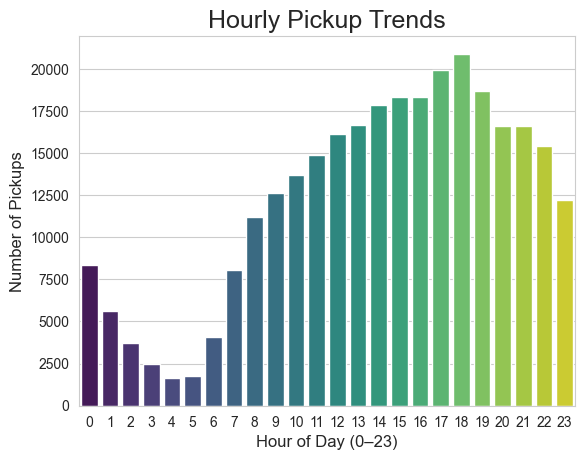

In [89]:
# Find and show the hourly trends in taxi pickups
df['pickup_hour']=df["tpep_pickup_datetime"].dt.hour
hourly_counts=df['pickup_hour'].value_counts().sort_index()
sns.set_style("whitegrid")
sns.barplot(x=hourly_counts.index, y=hourly_counts.values, palette="viridis")
plt.title('Hourly Pickup Trends', fontsize=18)
plt.xlabel('Hour of Day (0–23)', fontsize=12)
plt.ylabel('Number of Pickups', fontsize=12)
plt.xticks(range(0, 24))
plt.show()



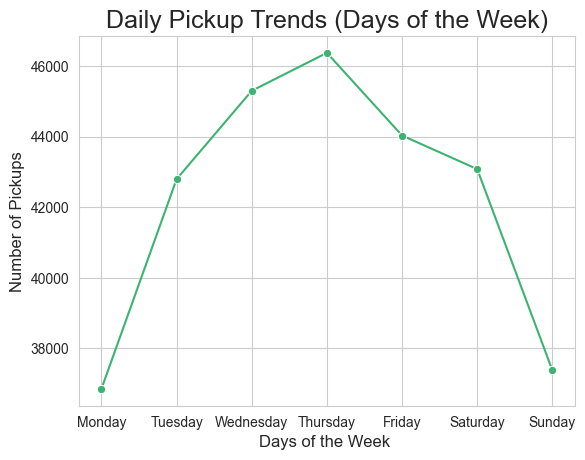

In [91]:
# Find and show the daily trends in taxi pickups (days of the week)
df['pickup_day_of_the_week']=df['tpep_pickup_datetime'].dt.day_of_week
dayCounts=df['pickup_day_of_the_week'].value_counts().sort_index()
sns.lineplot(x=dayCounts.index, y=dayCounts.values, marker='o', color='mediumseagreen')

# Add title and labels
plt.title('Daily Pickup Trends (Days of the Week)', fontsize=18)
plt.xlabel('Days of the Week ', fontsize=12)
plt.ylabel('Number of Pickups', fontsize=12)
plt.xticks(ticks=dayCounts.index, labels=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.show()



C:\Users\harsh\AppData\Local\Temp\ipykernel_32380\2282190806.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthlyCounts.index, y=monthlyCounts.values, palette="flare")


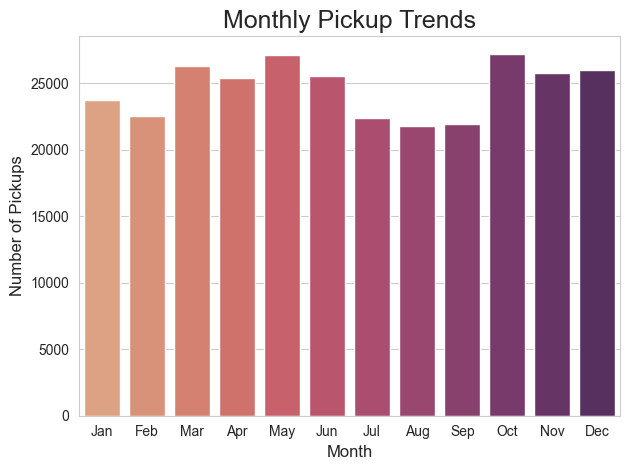

In [93]:
# Show the monthly trends in pickups
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
df['monthly_pickups']=df['tpep_pickup_datetime'].dt.month
monthlyCounts=df['monthly_pickups'].value_counts().sort_index()
sns.barplot(x=monthlyCounts.index, y=monthlyCounts.values, palette="flare")
plt.xticks(ticks=range(0, 12), labels=month_labels)
plt.title('Monthly Pickup Trends', fontsize=18)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Pickups', fontsize=12)
plt.tight_layout()
plt.show()



##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [95]:
# Analyse the above parameters
# Yes it does contain 0 values
zeroValues=df[['fare_amount','tip_amount','total_amount','trip_distance']]==0
zeroValues.sum(axis=0)



fare_amount         81
tip_amount       67951
total_amount        34
trip_distance     5825
dtype: int64

Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

Yes, Because we can have both the dataframe that can be used for comparing the insights.


**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [97]:
# Create a df with non zero entries for the selected parameters.
new_df=df[~((df['fare_amount']==0)|(df['tip_amount']==0)|(df['total_amount']==0)|(df['trip_distance']==0))]

**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

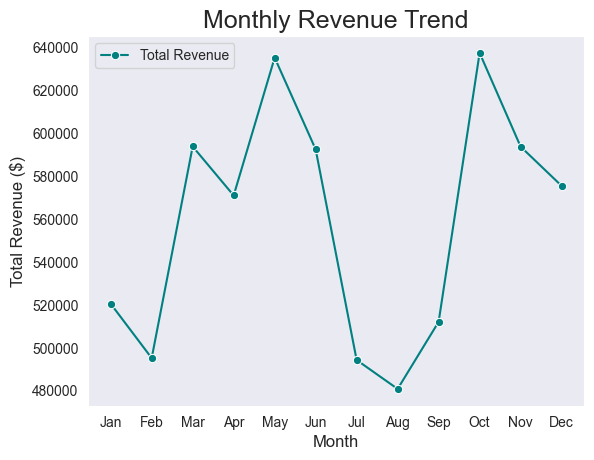

In [99]:
# Group data by month and analyse monthly revenue
monthlyRevenue=new_df.groupby('monthly_pickups')['total_amount'].sum().sort_index()
sns.set_style("dark")
sns.lineplot(x=monthlyRevenue.index, y=monthlyRevenue.values, marker='o', color='teal', label='Total Revenue')
plt.xticks(ticks=range(1, 13), labels=month_labels)
plt.title('Monthly Revenue Trend', fontsize=18)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.show()



**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

In [101]:
new_df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,standardised_tip_amount,pickup_hour,pickup_day_of_the_week,monthly_pickups
1,2,2023-01-21 21:39:38,2023-01-21 21:56:27,1.0,1.42,1.0,113,148,1,14.9,...,2.98,0.0,1.0,22.88,2.5,0.0,-0.139654,21,5,1
2,2,2023-01-21 21:32:31,2023-01-21 21:43:23,2.0,2.31,1.0,237,238,1,13.5,...,2.50,0.0,1.0,21.00,2.5,0.0,-0.258361,21,5,1
3,2,2023-01-21 21:36:00,2023-01-21 21:46:25,1.0,1.37,1.0,113,246,1,11.4,...,2.95,0.0,1.0,19.35,2.5,0.0,-0.147073,21,5,1
4,2,2023-01-21 21:47:14,2023-01-21 21:55:09,3.0,1.42,1.0,261,125,1,10.0,...,3.00,0.0,1.0,18.00,2.5,0.0,-0.134708,21,5,1
6,2,2023-01-21 21:40:36,2023-01-21 22:04:13,2.0,5.18,1.0,170,166,1,27.5,...,6.50,0.0,1.0,39.00,2.5,0.0,0.730864,21,5,1


C:\Users\harsh\AppData\Local\Temp\ipykernel_32380\3528759789.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['quarter_pickups']=df['tpep_pickup_datetime'].dt.quarter
C:\Users\harsh\AppData\Local\Temp\ipykernel_32380\3528759789.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=quarterRevenue.index, y=quarterRevenue.values, palette="crest")


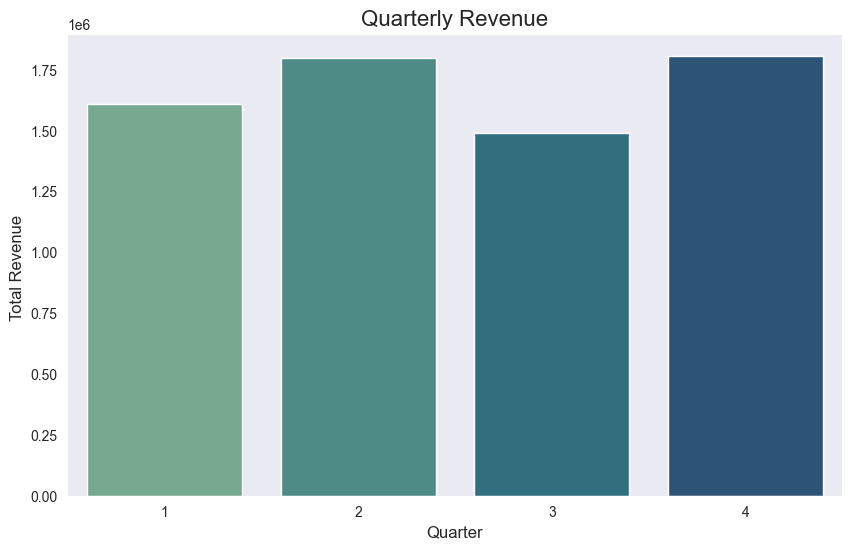

In [103]:
# Calculate proportion of each quarter
new_df['quarter_pickups']=df['tpep_pickup_datetime'].dt.quarter
quarterRevenue=new_df.groupby('quarter_pickups')['total_amount'].sum().sort_index()
quarterRevenue.values
sns.set_style("dark")
plt.figure(figsize=(10, 6))
sns.barplot(x=quarterRevenue.index, y=quarterRevenue.values, palette="crest")
plt.title('Quarterly Revenue', fontsize=16)
plt.xlabel('Quarter', fontsize=12)
plt.ylabel('Total Revenue ', fontsize=12)
plt.show()



**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

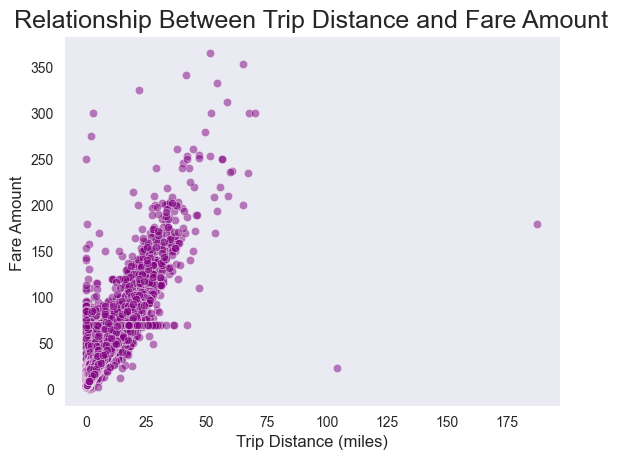

In [105]:
# Show how trip fare is affected by distance
sns.scatterplot(data=new_df, x='trip_distance', y='fare_amount', alpha=0.5, color='purple')
# Add title and labels
plt.title('Relationship Between Trip Distance and Fare Amount', fontsize=18)
plt.xlabel('Trip Distance (miles)', fontsize=12)
plt.ylabel('Fare Amount ', fontsize=12)
plt.show()


In [107]:
# Correlation between these two values
print("Correlation between these two values",new_df['trip_distance'].corr(new_df['fare_amount']))

Correlation between these two values 0.9477332679223517


**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

C:\Users\harsh\AppData\Local\Temp\ipykernel_32380\1867169259.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['trip_duration'] = (new_df['tpep_dropoff_datetime'] - new_df['tpep_pickup_datetime']).dt.total_seconds() / 60 #in minutes


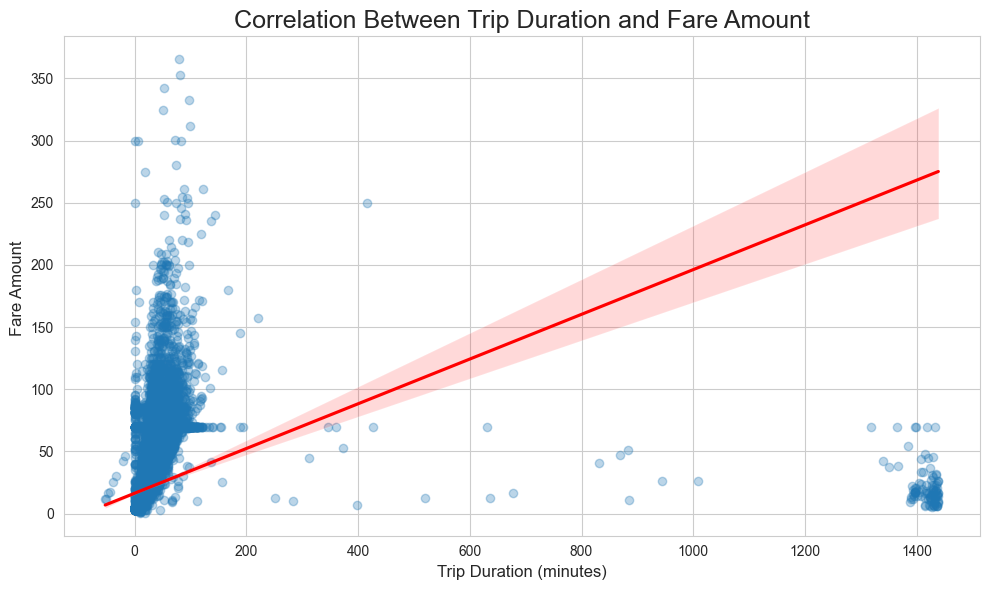

In [109]:
# Show relationship between fare and trip duration
new_df['trip_duration'] = (new_df['tpep_dropoff_datetime'] - new_df['tpep_pickup_datetime']).dt.total_seconds() / 60 #in minutes
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.regplot(data=new_df, x='trip_duration', y='fare_amount',scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'})
plt.title('Correlation Between Trip Duration and Fare Amount', fontsize=18)
plt.xlabel('Trip Duration (minutes)', fontsize=12)
plt.ylabel('Fare Amount ', fontsize=12)
plt.tight_layout()
plt.show()



In [600]:
new_df['fare_amount'].corr(new_df['trip_duration'])

0.34034406733949396

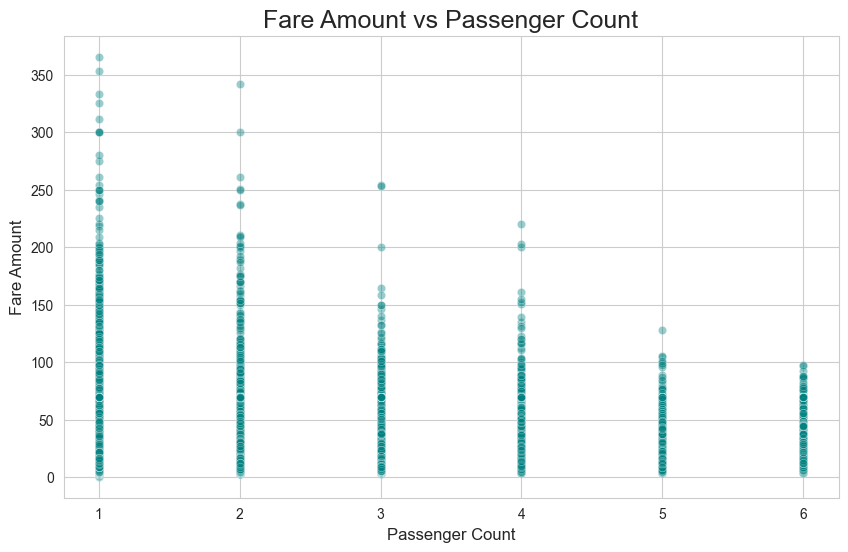

In [111]:
# Show relationship between fare and number of passengers
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.scatterplot(data=new_df, x='passenger_count', y='fare_amount', alpha=0.4, color='teal')
plt.title('Fare Amount vs Passenger Count', fontsize=18)
plt.xlabel('Passenger Count', fontsize=12)
plt.ylabel('Fare Amount', fontsize=12)
plt.show()



In [602]:
new_df['fare_amount'].corr(new_df['passenger_count'])

0.035945752909339504

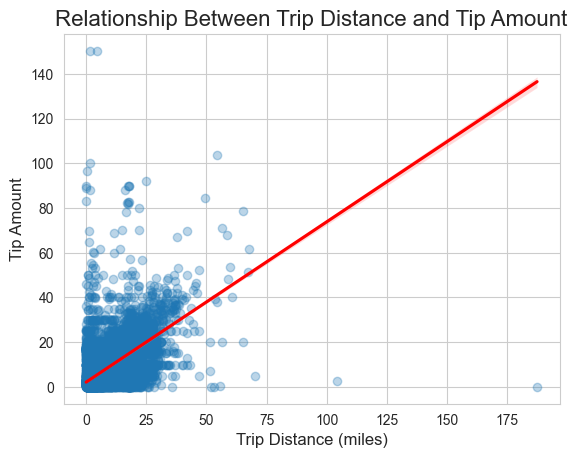

In [113]:
# Show relationship between tip and trip distance
sns.regplot(data=new_df, x='trip_distance', y='tip_amount',scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'})
plt.title('Relationship Between Trip Distance and Tip Amount', fontsize=16)
plt.xlabel('Trip Distance (miles)', fontsize=12)
plt.ylabel('Tip Amount', fontsize=12)
plt.show()




In [606]:
new_df['tip_amount'].corr(new_df['trip_distance'])

0.793355017857964

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

C:\Users\harsh\AppData\Local\Temp\ipykernel_32380\2573171462.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['payment_type_label']=new_df['payment_type'].map(paymentMap)
C:\Users\harsh\AppData\Local\Temp\ipykernel_32380\2573171462.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=new_df, x='payment_type_label', palette='Set2')


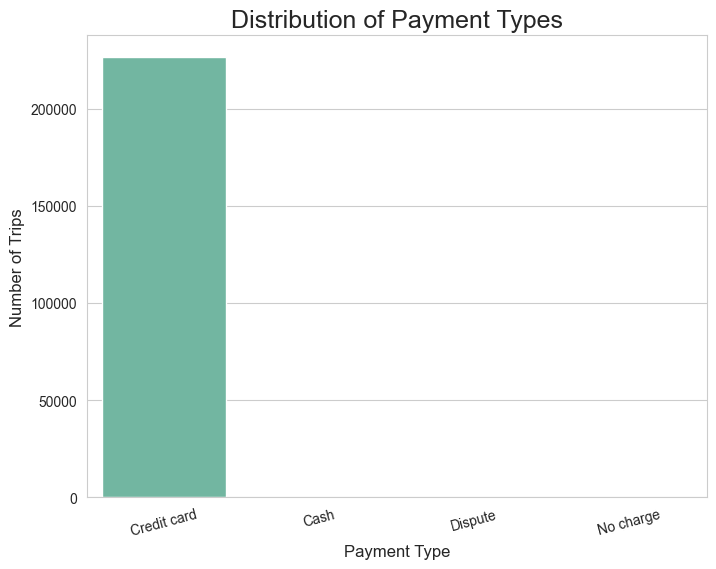

In [117]:
# Analyse the distribution of different payment types (payment_type).
paymentMap={1: 'Credit card',
2: 'Cash',
3: 'No charge',
4: 'Dispute',
5: 'Unknown',
6: 'Voided trip'}
new_df['payment_type_label']=new_df['payment_type'].map(paymentMap)
sns.set_style("whitegrid")
plt.figure(figsize=(8, 6))
sns.countplot(data=new_df, x='payment_type_label', palette='Set2')
plt.title('Distribution of Payment Types', fontsize=18)
plt.xlabel('Payment Type', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
plt.xticks(rotation=15)
plt.show()




- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [ ]:
# !pip install geopandas
!pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [127]:
# import geopandas as gpd

import geopandas as gpd
# Read the shapefile using geopandas
shapefile_path ="../taxi_zones/taxi_zones.shp"
zones = gpd.read_file(shapefile_path)# read the .shp file using gpd
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

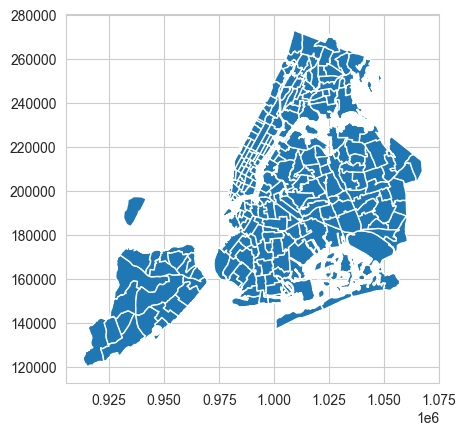

In [129]:
# print(zones.info())
print(zones.info())
# zones.plot()
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [131]:
# Merge zones and trip records using locationID and PULocationID
merge_df=pd.merge(new_df, zones, left_on='PULocationID', right_on='LocationID', how='inner')
merge_df.head()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,quarter_pickups,trip_duration,payment_type_label,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,2,2023-01-21 21:39:38,2023-01-21 21:56:27,1.0,1.42,1.0,113,148,1,14.9,...,1,16.816667,Credit card,113,0.032745,0.000058,Greenwich Village North,113,Manhattan,"POLYGON ((986643.64 204346.324, 986592.535 204..."
1,2,2023-01-21 21:32:31,2023-01-21 21:43:23,2.0,2.31,1.0,237,238,1,13.5,...,1,10.866667,Credit card,237,0.042213,0.000096,Upper East Side South,237,Manhattan,"POLYGON ((993633.442 216961.016, 993507.232 21..."
2,2,2023-01-21 21:36:00,2023-01-21 21:46:25,1.0,1.37,1.0,113,246,1,11.4,...,1,10.416667,Credit card,113,0.032745,0.000058,Greenwich Village North,113,Manhattan,"POLYGON ((986643.64 204346.324, 986592.535 204..."
3,2,2023-01-21 21:47:14,2023-01-21 21:55:09,3.0,1.42,1.0,261,125,1,10.0,...,1,7.916667,Credit card,261,0.027120,0.000034,World Trade Center,261,Manhattan,"POLYGON ((980555.204 196138.486, 980570.792 19..."
4,2,2023-01-21 21:40:36,2023-01-21 22:04:13,2.0,5.18,1.0,170,166,1,27.5,...,1,23.616667,Credit card,170,0.045769,0.000074,Murray Hill,170,Manhattan,"POLYGON ((991999.299 210994.739, 991972.635 21..."


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [133]:
# Group data by location and calculate the number of trips
tripsByLocation=merge_df['LocationID'].value_counts().sort_index()
print("Trips by Location \n",tripsByLocation)



Trips by Location 
 LocationID
1         4
4       255
6         1
7        52
9         1
       ... 
258       1
260      19
261    1128
262    3160
263    4477
Name: count, Length: 177, dtype: int64


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [135]:
# Merge trip counts back to the zones GeoDataFrame
zones['trips']=zones['LocationID'].map(tripsByLocation)


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

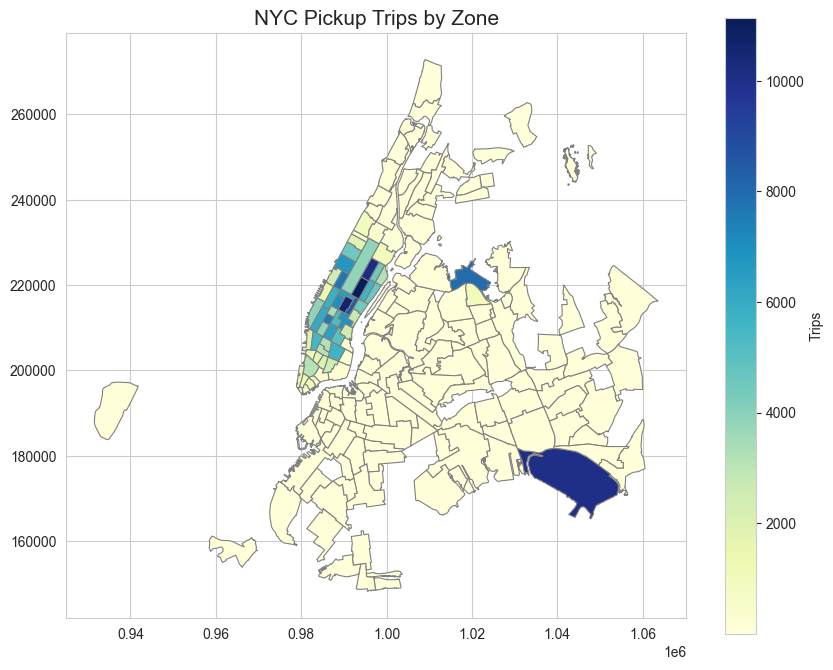

In [137]:
# Define figure and axis
fig, ax=plt.subplots(1,1,figsize=(10,8))

# Plot the map and display it
zones.plot(column='trips',cmap='YlGnBu',linewidth=0.8,edgecolor='grey',legend=True,ax=ax,legend_kwds={'label':"Trips",'orientation':"vertical"})

ax.set_title("NYC Pickup Trips by Zone", fontsize=15)
plt.show()



In [139]:
# can you try displaying the zones DF sorted by the number of trips?

sorted_zones=zones.sort_values('trips')
print(sorted_zones.head())

     OBJECTID  Shape_Leng  Shape_Area                zone  LocationID borough  \
91         92    0.117830    0.000375            Flushing          92  Queens   
168       169    0.060105    0.000146          Mount Hope         169   Bronx   
45         46    0.134475    0.000926         City Island          46   Bronx   
46         47    0.089828    0.000163  Claremont/Bathgate          47   Bronx   
166       167    0.090816    0.000168  Morrisania/Melrose         167   Bronx   

                                              geometry  trips  
91   POLYGON ((1032288.994 220089.809, 1032291.399 ...    1.0  
168  POLYGON ((1012420.96 250846.784, 1012291.557 2...    1.0  
45   MULTIPOLYGON (((1043853.395 252845.891, 104386...    1.0  
46   POLYGON ((1014430.835 250474.121, 1014081.534 ...    1.0  
166  POLYGON ((1012781.409 242061.913, 1012706.412 ...    1.0  


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [189]:
# Find routes which have the slowest speeds at different times of the day
new_df["route"]=new_df["PULocationID"].astype('str')+"->"+new_df["DOLocationID"].astype(str)
new_df["trip_duration"]=(new_df["tpep_dropoff_datetime"]-new_df["tpep_pickup_datetime"]).dt.total_seconds()/3600
tripDetails=new_df.groupby(["route","trip_distance","pickup_hour"])["trip_duration"].mean().reset_index()

tripDetails["speed"]=tripDetails["trip_distance"]/tripDetails["trip_duration"]
tripDetails=tripDetails[tripDetails["trip_duration"]>0]
tripDetails.sort_values("speed")
tripDetails.loc[tripDetails.groupby('route')['speed'].idxmin()]


C:\Users\harsh\AppData\Local\Temp\ipykernel_32380\91114658.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df["route"]=new_df["PULocationID"].astype('str')+"->"+new_df["DOLocationID"].astype(str)
C:\Users\harsh\AppData\Local\Temp\ipykernel_32380\91114658.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df["trip_duration"]=(new_df["tpep_dropoff_datetime"]-new_df["tpep_pickup_datetime"]).dt.total_seconds()/3600


,route,trip_distance,pickup_hour,trip_duration,speed
1,1->1,0.01,11,0.032500,0.307692
3,1->265,0.07,16,0.003889,18.000000
4,10->100,15.47,20,0.877778,17.624051
5,10->13,19.69,16,0.908056,21.683695
6,10->131,6.25,15,0.359167,17.401392
...,...,...,...,...,...
211816,97->65,0.56,21,0.055833,10.029851
211818,97->66,1.30,19,0.173889,7.476038
211820,97->68,4.99,21,0.404722,12.329444
211821,97->76,6.12,20,0.494444,12.377528


How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

C:\Users\harsh\AppData\Local\Temp\ipykernel_32380\1576274100.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=taxiPickups.index, y=taxiPickups.values, palette='viridis')


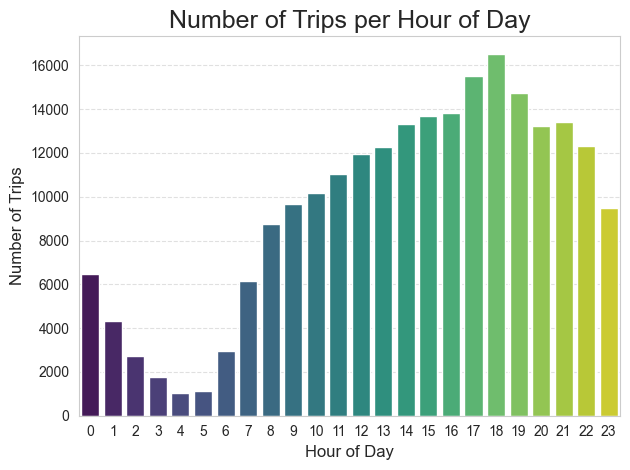

In [203]:
# Visualise the number of trips per hour and find the busiest hour
taxiPickups=new_df["pickup_hour"].value_counts().sort_index()
sns.barplot(x=taxiPickups.index, y=taxiPickups.values, palette='viridis')
plt.title('Number of Trips per Hour of Day', fontsize=18)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
plt.xticks(range(24))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()




In [205]:
#busiest Hour
busiest_hour = taxiPickups.idxmax()
trip_count = taxiPickups.max()
print(f"Busiest hour: {busiest_hour}:00 with {trip_count} trips")

Busiest hour: 18:00 with 16497 trips


Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [219]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction =0.0078
scale_factor = 1 / sample_fraction
scalePickups=taxiPickups*scale_factor
scalePickups.sort_values(ascending=False).head(5)
print("five busiest hours \n", scalePickups.sort_values(ascending=False).head(5))




five busiest hours 
 pickup_hour
18    2.115000e+06
17    1.990769e+06
19    1.889872e+06
16    1.769615e+06
15    1.753718e+06
Name: count, dtype: float64


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

C:\Users\harsh\AppData\Local\Temp\ipykernel_32380\1158082813.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df["week_day_weekend"]=new_df["pickup_day_of_the_week"].map(lambda x:"Week Day" if x in [0,1,2,3,4] else "Weekend" )
C:\Users\harsh\AppData\Local\Temp\ipykernel_32380\1158082813.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekdayComparison.index, y=weekdayComparison.values, palette='PuBu')


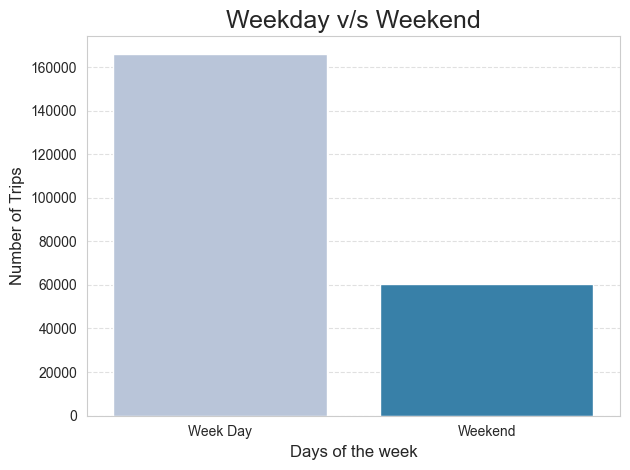

In [239]:
# Compare traffic trends for the week days and weekends

new_df["week_day_weekend"]=new_df["pickup_day_of_the_week"].map(lambda x:"Week Day" if x in [0,1,2,3,4] else "Weekend" )
weekdayComparison=new_df["week_day_weekend"].value_counts()
sns.barplot(x=weekdayComparison.index, y=weekdayComparison.values, palette='PuBu')
plt.title('Weekday v/s Weekend', fontsize=18)
plt.xlabel('Days of the week', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
plt.xticks(range(2))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [530]:
# Find top 10 pickup and dropoff zones
drop_location_df=pd.merge(new_df, zones, left_on='DOLocationID', right_on='LocationID', how='inner')
dropZones=drop_location_df['LocationID'].value_counts().sort_index()
zones["dropped_trips"]=zones["LocationID"].map(dropZones)
print("top 10 pickup zones\n", zones.sort_values("trips",ascending=False)[["zone","trips"]].head(10))
print("\n")
print("top 10 drop off zones\n", zones.sort_values("dropped_trips",ascending=False)[["zone","dropped_trips"]].head(10))



top 10 pickup zones
                              zone    trips
236         Upper East Side South  11148.0
160                Midtown Center  10640.0
235         Upper East Side North  10150.0
131                   JFK Airport  10038.0
161                  Midtown East   8450.0
137             LaGuardia Airport   8004.0
141           Lincoln Square East   7723.0
185  Penn Station/Madison Sq West   7587.0
229     Times Sq/Theatre District   7025.0
169                   Murray Hill   6828.0


top 10 drop off zones
                           zone  dropped_trips
235      Upper East Side North        10809.0
236      Upper East Side South         9855.0
160             Midtown Center         8907.0
169                Murray Hill         6901.0
238      Upper West Side South         6805.0
141        Lincoln Square East         6644.0
161               Midtown East         6586.0
140            Lenox Hill West         6321.0
229  Times Sq/Theatre District         6162.0
67                Eas

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,trips,dropped_trips,ratio_pickup_drop,average_passenger_count
235,236,0.044252,0.000103,Upper East Side North,236,Manhattan,"POLYGON ((995940.048 221122.92, 995812.322 220...",10150.0,10809.0,0.939032,1.344433


**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [608]:
# Find the top 10 and bottom 10 pickup/dropoff ratios
zones["ratio_pickup_drop"]=zones["trips"]/zones["dropped_trips"]
print("top 10 highest ratio zones\n", zones.sort_values("ratio_pickup_drop",ascending=False)[["zone","ratio_pickup_drop"]].head(10))
print("\n")
print("lowest 10 ratio zones\n", zones.sort_values("ratio_pickup_drop",ascending=True)[["zone","ratio_pickup_drop"]].head(10))




top 10 highest ratio zones
                              zone  ratio_pickup_drop
69                  East Elmhurst          13.421053
131                   JFK Airport           4.317419
137             LaGuardia Airport           2.591969
185  Penn Station/Madison Sq West           1.575374
214                 South Jamaica           1.533333
42                   Central Park           1.381499
248                  West Village           1.374594
113       Greenwich Village South           1.344828
161                  Midtown East           1.283025
99               Garment District           1.215835


lowest 10 ratio zones
                    zone  ratio_pickup_drop
0        Newark Airport           0.006116
13            Bay Ridge           0.008197
256     Windsor Terrace           0.009615
91             Flushing           0.011905
201    Roosevelt Island           0.016529
195           Rego Park           0.024390
224  Stuyvesant Heights           0.028736
197           Ridgew

**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [612]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones
pickupInNight=merge_df[(merge_df['pickup_hour']<=5)| (merge_df['pickup_hour']==23)]
pickupInNight['zone'].value_counts()
print("Top 10 zone pick up during night hours \n",pickupInNight['zone'].value_counts().head(10))
print("\n")
drop_location_df['drop_hour']=drop_location_df["tpep_dropoff_datetime"].dt.hour
dropInNight=drop_location_df[(drop_location_df['drop_hour']<=5)| (drop_location_df['drop_hour']==23)]
print("Top 10 drop off zone during night hours \n",dropInNight['zone'].value_counts().head(10))




Top 10 zone pick up during night hours 
 zone
East Village                    2079
West Village                    1729
JFK Airport                     1524
Lower East Side                 1312
Clinton East                    1260
Greenwich Village South         1121
Times Sq/Theatre District        983
Penn Station/Madison Sq West     843
LaGuardia Airport                769
Gramercy                         750
Name: count, dtype: int64


Top 10 drop off zone during night hours 
 zone
East Village             1167
Clinton East              901
Murray Hill               862
Gramercy                  812
Lenox Hill West           807
East Chelsea              794
Yorkville West            771
Upper East Side North     717
West Village              698
Upper West Side South     667
Name: count, dtype: int64


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [355]:
# Filter for night hours (11 PM to 5 AM)
pickupInNight['total_amount'].sum()
dayTimeRides=merge_df[~((merge_df['pickup_hour']<=5)| (merge_df['pickup_hour']==23))]
dayTimeRides["total_amount"].sum().round(2)

print("revenue share for night time ",pickupInNight['total_amount'].sum().round(2))
print("\n")
print("revenue share for day time ",dayTimeRides['total_amount'].sum().round(2))





revenue share for night time  805383.57


revenue share for day time  5834403.93


##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

C:\Users\harsh\AppData\Local\Temp\ipykernel_32380\1320995324.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avgFarePersonPerMile.index, y=avgFarePersonPerMile.values, palette='PuBu')


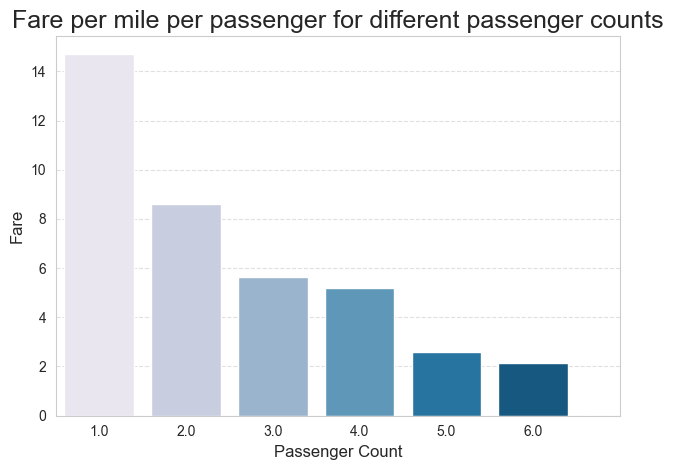

In [381]:
# Analyse the fare per mile per passenger for different passenger counts
merge_df["average_fare_per_mile"]=merge_df['total_amount']/merge_df['trip_distance']
merge_df["average_fare_per_mile_pass"]=merge_df["average_fare_per_mile"]/merge_df['passenger_count']
merge_df[['total_amount','passenger_count','average_fare_per_mile','average_fare_per_mile_pass']]
avgFarePersonPerMile=merge_df.groupby("passenger_count")["average_fare_per_mile_pass"].mean()
sns.barplot(x=avgFarePersonPerMile.index, y=avgFarePersonPerMile.values, palette='PuBu')
plt.title('Fare per mile per passenger for different passenger counts', fontsize=18)
plt.xlabel('Passenger Count', fontsize=12)
plt.ylabel('Fare', fontsize=12)
plt.xticks(range(7))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [614]:
avgFarePersonPerMile


passenger_count
1.0    14.689415
2.0     8.587225
3.0     5.627111
4.0     5.209289
5.0     2.575920
6.0     2.146256
Name: average_fare_per_mile_pass, dtype: float64

**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

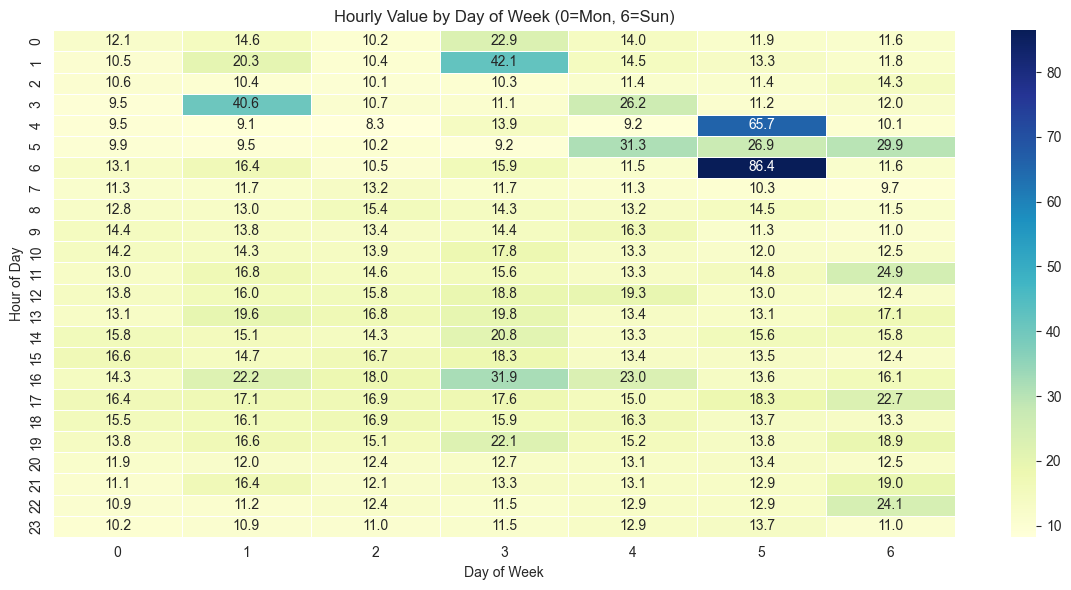

In [397]:
# Compare the average fare per mile for different days and for different times of the day
comparisonWithDays=merge_df.groupby(["pickup_day_of_the_week","pickup_hour"])["average_fare_per_mile"].mean().reset_index()
pivotDf= comparisonWithDays.pivot_table(
    index='pickup_hour', 
    columns='pickup_day_of_the_week', 
    values='average_fare_per_mile'  
)
plt.figure(figsize=(12, 6))
sns.heatmap(pivotDf,cmap='YlGnBu',annot=True, fmt=".1f",linewidths=0.5)
plt.title('Hourly Value by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Hour of Day')
plt.tight_layout()
plt.show()



**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

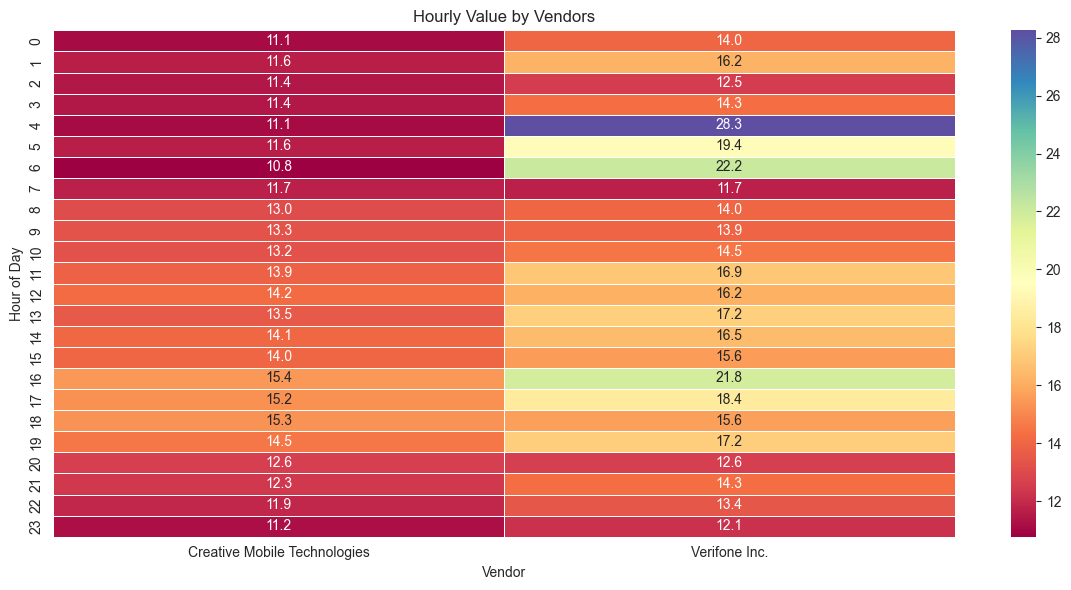

In [411]:
# Compare fare per mile for different vendors
comparisonWithVendors=merge_df.groupby(["VendorID","pickup_hour"])["average_fare_per_mile"].mean().reset_index()
vendorNames = ['Creative Mobile Technologies','Verifone Inc.']
pivotDf= comparisonWithVendors.pivot_table(
    index='pickup_hour', 
    columns='VendorID', 
    values='average_fare_per_mile'  
)
plt.figure(figsize=(12, 6))
sns.heatmap(pivotDf,cmap='Spectral',annot=True, fmt=".1f",linewidths=0.5,xticklabels=vendorNames)
plt.title('Hourly Value by Vendors')
plt.xlabel('Vendor')
plt.ylabel('Hour of Day')
plt.tight_layout()
plt.show()


**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


In [423]:
# Defining distance tiers
vendor_map = {
    1: 'Creative Mobile Technologies',
    2: 'VeriFone Inc.'
}
def get_tiers(val):
    if val <= 2:
        return '0–2 miles'
    elif val <= 5:
        return '2–5 miles'
    else:
        return '5+ miles'
merge_df["distance_tiers"]=merge_df["trip_distance"].apply(get_tiers)
distanceTierDf=merge_df.groupby(["VendorID","distance_tiers"])["average_fare_per_mile"].mean().reset_index()
distanceTierDf["vendorName"]=distanceTierDf["VendorID"].map(vendor_map)
pivotView=distanceTierDf.pivot_table( index='distance_tiers', 
    columns='vendorName', 
    values='average_fare_per_mile')
print(pivotView)
    



vendorName      Creative Mobile Technologies  VeriFone Inc.
distance_tiers                                             
0–2 miles                          17.144266      22.106027
2–5 miles                           9.518241       9.716557
5+ miles                            6.381656       6.406772


##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

C:\Users\harsh\AppData\Local\Temp\ipykernel_32380\532590825.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=distanceVsTip, x='distance_tiers', y='tip_percent', palette='coolwarm')


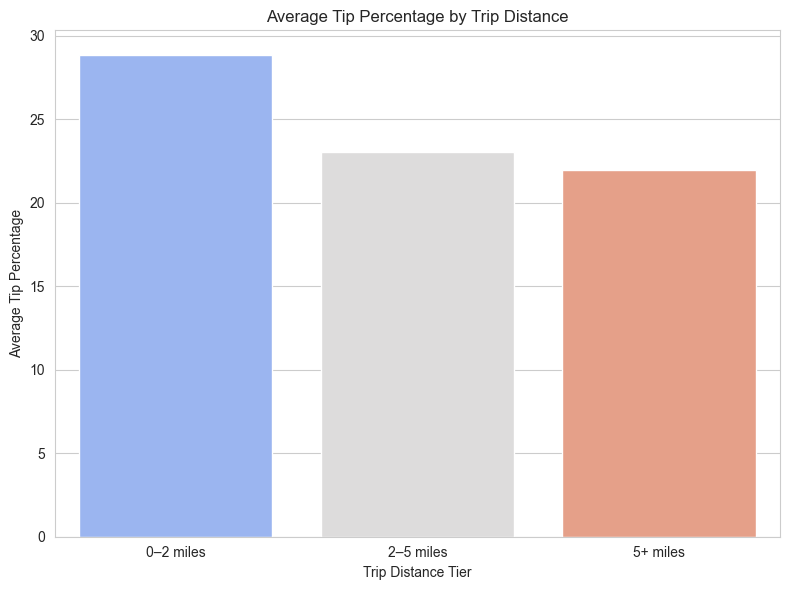

In [437]:
#  Analyze tip percentages based on distances, passenger counts and pickup times
merge_df["tip_percent"]=(merge_df['tip_amount'] / merge_df['fare_amount']) * 100

# tip percentage by Trip distance
distanceVsTip=merge_df.groupby('distance_tiers')['tip_percent'].mean().reset_index()
plt.figure(figsize=(8, 6))
sns.barplot(data=distanceVsTip, x='distance_tiers', y='tip_percent', palette='coolwarm')
plt.title('Average Tip Percentage by Trip Distance')
plt.xlabel('Trip Distance Tier')
plt.ylabel('Average Tip Percentage')
plt.tight_layout()
plt.show()




C:\Users\harsh\AppData\Local\Temp\ipykernel_32380\454935288.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=distanceVsTip, x='passenger_count', y='tip_percent', palette='Blues')


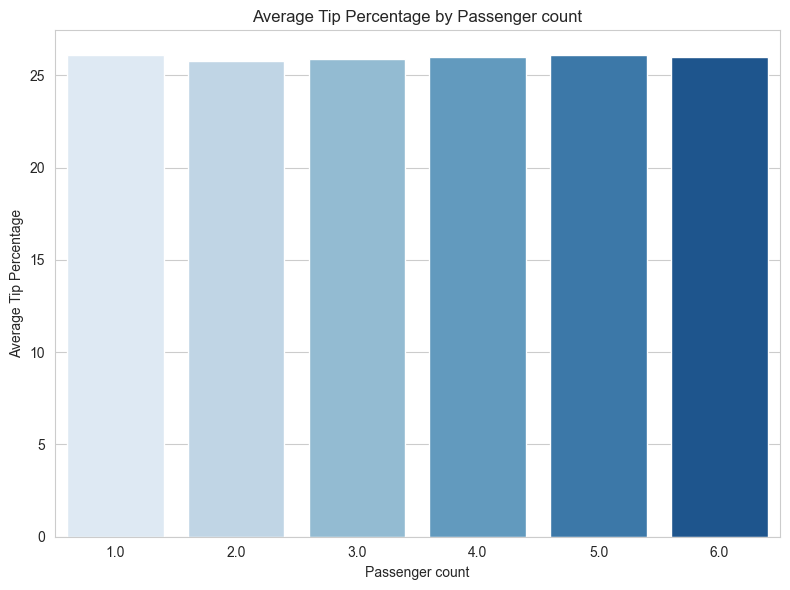

In [441]:
# tip percentage by Passenger count
distanceVsTip=merge_df.groupby('passenger_count')['tip_percent'].mean().reset_index()
plt.figure(figsize=(8, 6))
sns.barplot(data=distanceVsTip, x='passenger_count', y='tip_percent', palette='Blues')
plt.title('Average Tip Percentage by Passenger count')
plt.xlabel('Passenger count')
plt.ylabel('Average Tip Percentage')
plt.tight_layout()
plt.show()

C:\Users\harsh\AppData\Local\Temp\ipykernel_32380\2259562237.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=distanceVsTip, x='pickup_hour', y='tip_percent', palette='pastel')


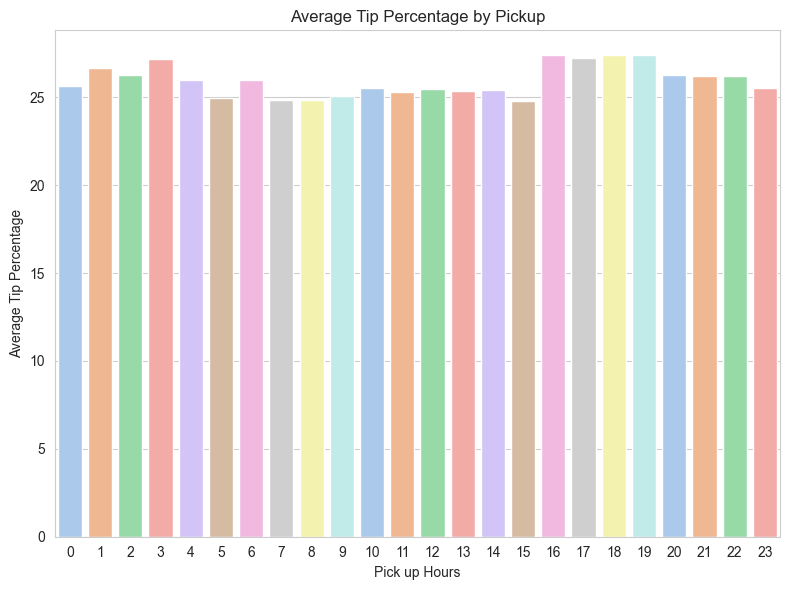

In [445]:
# tip percentage by pickuphour
distanceVsTip=merge_df.groupby('pickup_hour')['tip_percent'].mean().reset_index()
plt.figure(figsize=(8, 6))
sns.barplot(data=distanceVsTip, x='pickup_hour', y='tip_percent', palette='pastel')
plt.title('Average Tip Percentage by Pickup')
plt.xlabel('Pick up Hours')
plt.ylabel('Average Tip Percentage')
plt.tight_layout()
plt.show()

Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [469]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%
tripsWithlowPercentage=len(merge_df[merge_df['tip_amount']<10])
tripsWithHighPercentage=len(merge_df[merge_df['tip_amount']>25])
tippingData = {
    'tip percentage < 10%': [tripsWithlowPercentage],
    'tip percentage > 25%': [tripsWithHighPercentage]
}
tip_df=pd.DataFrame(tippingData)
print(tip_df)


   tip percentage < 10%  tip percentage > 25%
0                203526                   493


**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

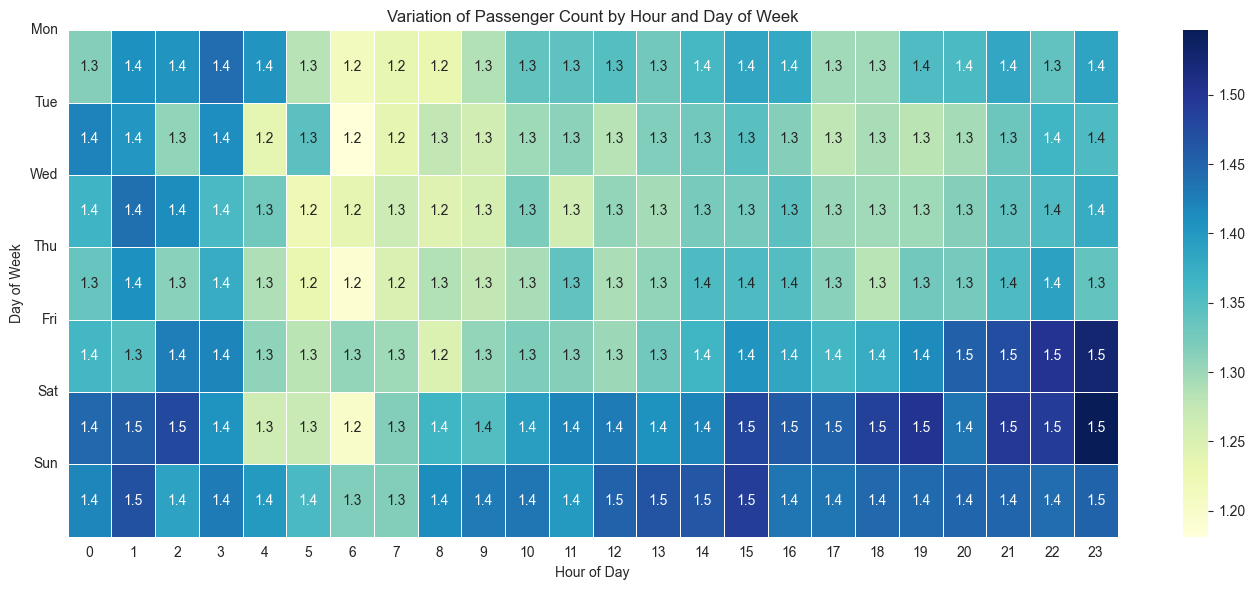

In [483]:
# See how passenger count varies across hours and days
grouped_df = merge_df.groupby(['pickup_day_of_the_week', 'pickup_hour'])['passenger_count'].mean().reset_index()
pivot_table = grouped_df.pivot(index='pickup_day_of_the_week', columns='pickup_hour', values='passenger_count')
plt.figure(figsize=(14, 6))
sns.heatmap(pivot_table, cmap='YlGnBu', linewidths=0.5, annot=True, fmt=".1f")
plt.title('Variation of Passenger Count by Hour and Day of Week')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.yticks(ticks=range(7), labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], rotation=0)
plt.tight_layout()
plt.show()



**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [489]:
# How does passenger count vary across zones
zones_df = merge_df.groupby(['zone'])['passenger_count'].mean().reset_index()
print("top 10 zones with max avg passenger_count \n",zones_df.sort_values('passenger_count',ascending=False).head(10))



top 10 zones with max avg passenger_count 
                         zone  passenger_count
26        Claremont/Bathgate             5.00
114          Oakland Gardens             3.50
1    Arrochar/Fort Wadsworth             3.00
102           Middle Village             2.50
34                    Corona             2.40
112           Newark Airport             2.25
96           Manhattan Beach             2.00
72           Highbridge Park             2.00
168            Willets Point             2.00
125           Queens Village             2.00


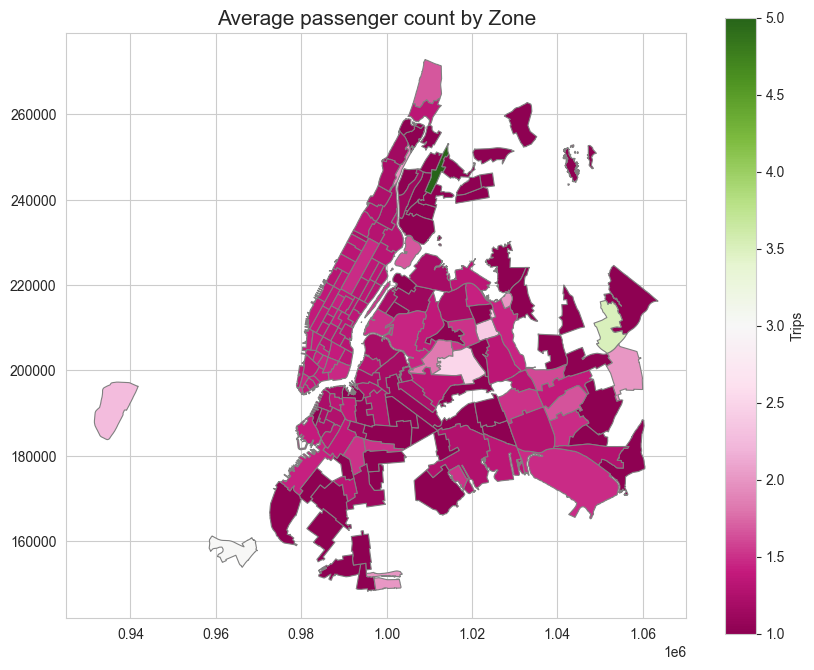

In [503]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.
zonesSeries=merge_df.groupby(['LocationID'])['passenger_count'].mean()
zones['average_passenger_count']=zones['LocationID'].map(zonesSeries)
fig, ax=plt.subplots(1,1,figsize=(10,8))

# Plot the map and display it
zones.plot(column='average_passenger_count',cmap='PiYG',linewidth=0.8,edgecolor='grey',legend=True,ax=ax,legend_kwds={'label':"Trips",'orientation':"vertical"})

ax.set_title("Average passenger count by Zone", fontsize=15)
plt.show()




Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

In [546]:
# How often is each surcharge applied?

merge_df['surcharge_total']=merge_df['improvement_surcharge']+merge_df['congestion_surcharge']+merge_df['extra']
print("Average surcharge based on pickup zones\n", merge_df.groupby('zone')['surcharge_total'].mean().reset_index().sort_values('surcharge_total',ascending=False).head(10))



Average surcharge based on pickup zones
                           zone  surcharge_total
87           LaGuardia Airport         8.997164
43               East Elmhurst         7.526765
25                 City Island         6.000000
103             Midtown Center         5.171194
153  Times Sq/Theatre District         5.162961
6            Battery Park City         5.087861
104               Midtown East         5.087799
105              Midtown North         5.070215
156        UN/Turtle Bay South         5.052090
157                   Union Sq         5.036641


In [616]:
drop_location_df['surcharge_total']=drop_location_df['improvement_surcharge']+drop_location_df['congestion_surcharge']+drop_location_df['extra']
print("Average surcharge based on Drop zones\n", drop_location_df.groupby('zone')['surcharge_total'].mean().reset_index().sort_values('surcharge_total',ascending=False).head(10))


Average surcharge based on Drop zones
                                zone  surcharge_total
124               LaGuardia Airport         8.518556
168                      Pelham Bay         7.000000
71                     East Tremont         6.916667
5                      Astoria Park         6.000000
235                   Willets Point         6.000000
139                     Marble Hill         6.000000
169                 Pelham Bay Park         6.000000
114                Inwood Hill Park         5.708333
104     Heartland Village/Todt Hill         5.500000
206  Stuy Town/Peter Cooper Village         5.346922


## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

Time of Day Strategy:
As hourly pickup trend shows the demand is more in the peak hours that is 9:00AM to 6:00PM in the evening. We need to increase the number of cabs to accomodate the surge in demand.

C:\Users\harsh\AppData\Local\Temp\ipykernel_32380\2089683835.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hourly_counts.index, y=hourly_counts.values, palette="viridis")


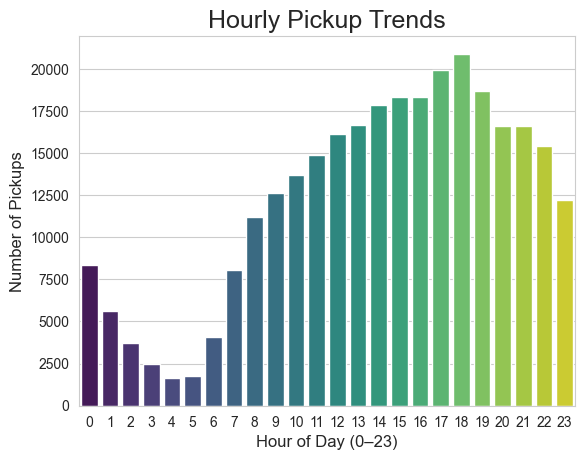

In [556]:
df['pickup_hour']=df["tpep_pickup_datetime"].dt.hour
hourly_counts=df['pickup_hour'].value_counts().sort_index()
sns.set_style("whitegrid")
sns.barplot(x=hourly_counts.index, y=hourly_counts.values, palette="viridis")
plt.title('Hourly Pickup Trends', fontsize=18)
plt.xlabel('Hour of Day (0–23)', fontsize=12)
plt.ylabel('Number of Pickups', fontsize=12)
plt.xticks(range(0, 24))
plt.show()


Days of the week strategy:
As we see the number of trips during weekdays are more as compared to weekends. Then We should increase focus on deploying more taxi of weedays .


C:\Users\harsh\AppData\Local\Temp\ipykernel_32380\1727690869.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekdayComparison.index, y=weekdayComparison.values, palette='PuBu')


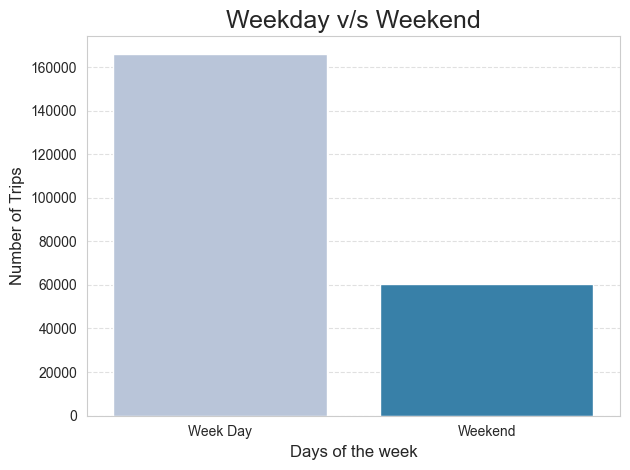

In [559]:
sns.barplot(x=weekdayComparison.index, y=weekdayComparison.values, palette='PuBu')
plt.title('Weekday v/s Weekend', fontsize=18)
plt.xlabel('Days of the week', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
plt.xticks(range(2))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Deploying SUV’s in zone where the demand of passenger count is more
Like deploying it in these zones


In [619]:
print("top 10 zones with max avg passenger_count \n",zones_df.sort_values('passenger_count',ascending=False).head(10))

top 10 zones with max avg passenger_count 
                         zone  passenger_count
26        Claremont/Bathgate             5.00
114          Oakland Gardens             3.50
1    Arrochar/Fort Wadsworth             3.00
102           Middle Village             2.50
34                    Corona             2.40
112           Newark Airport             2.25
96           Manhattan Beach             2.00
72           Highbridge Park             2.00
168            Willets Point             2.00
125           Queens Village             2.00


We see the tip decreases with the trip duration , so therefore there should be some standarised way of calculating the tip so that its good for people travelling for shorter distance

C:\Users\harsh\AppData\Local\Temp\ipykernel_32380\3641544436.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=distanceVsTip, x='distance_tiers', y='tip_percent', palette='coolwarm')


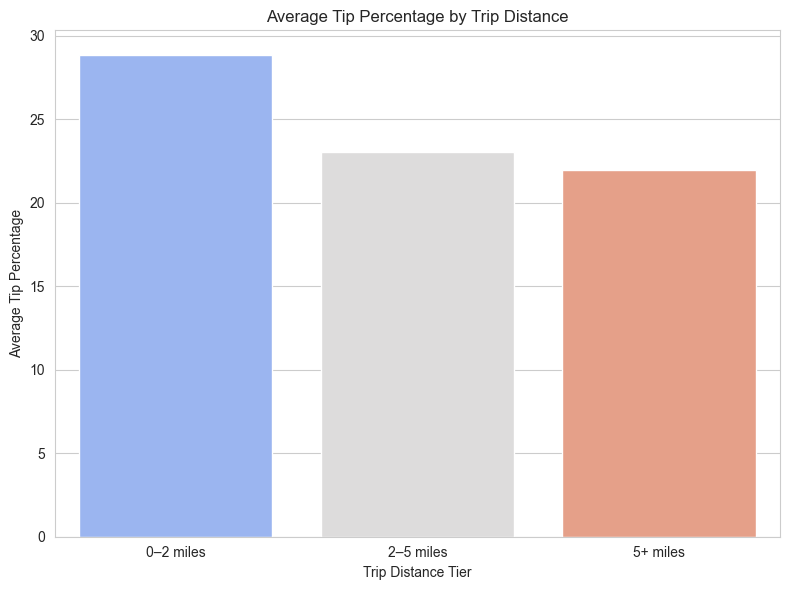

In [562]:
distanceVsTip=merge_df.groupby('distance_tiers')['tip_percent'].mean().reset_index()
plt.figure(figsize=(8, 6))
sns.barplot(data=distanceVsTip, x='distance_tiers', y='tip_percent', palette='coolwarm')
plt.title('Average Tip Percentage by Trip Distance')
plt.xlabel('Trip Distance Tier')
plt.ylabel('Average Tip Percentage')
plt.tight_layout()
plt.show()

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

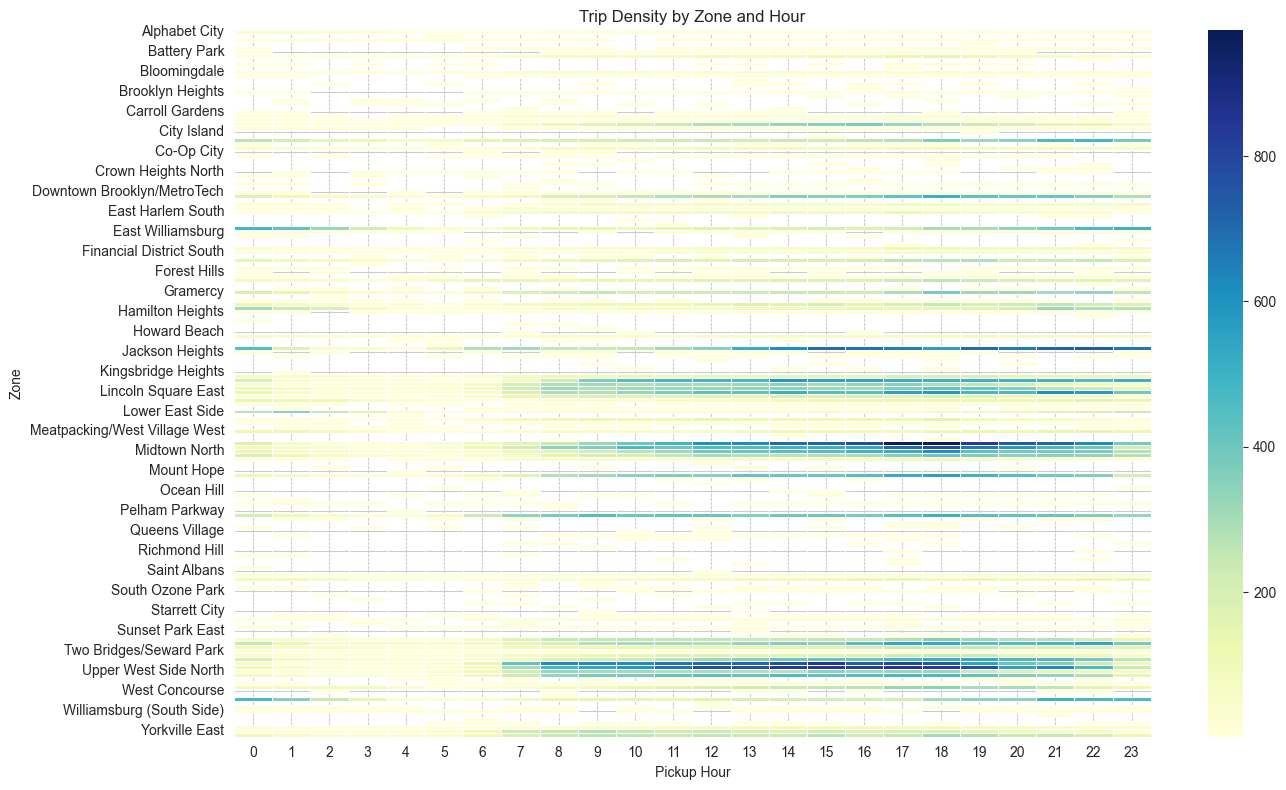

In [641]:
# Busiest zones
zone_hour = merge_df.groupby(['zone', 'pickup_hour']).size().reset_index(name='trip_count')
pivot_zone_hour = zone_hour.pivot(index='zone', columns='pickup_hour', values='trip_count')

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_zone_hour, cmap='YlGnBu', linewidths=0.5)
plt.title('Trip Density by Zone and Hour')
plt.xlabel('Pickup Hour')
plt.ylabel('Zone')
plt.tight_layout()
plt.show()


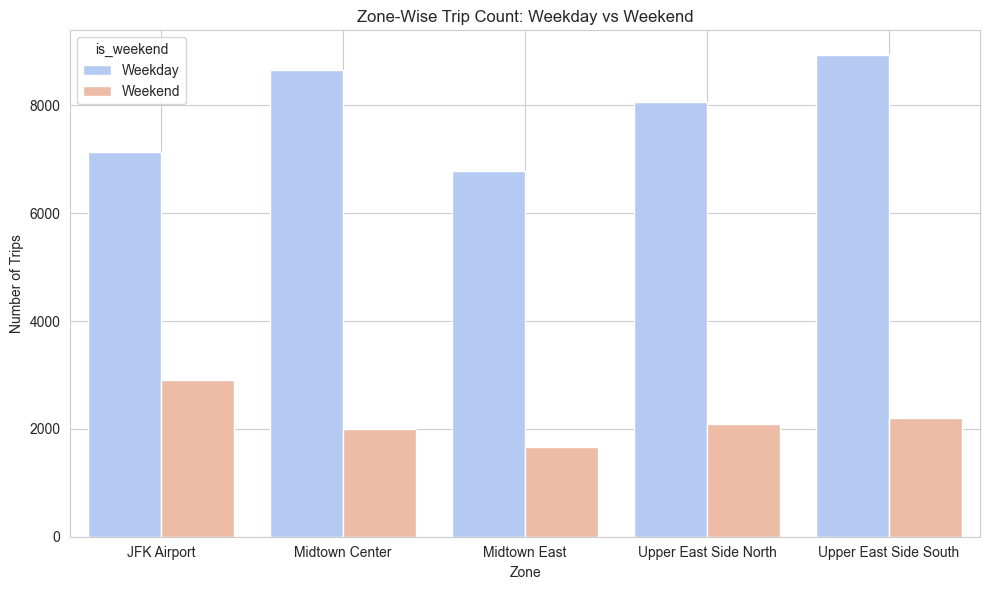

In [649]:
# Zone-wise Weekend vs Weekday Demand
top_zones = merge_df['zone'].value_counts().head(5).index
merge_df['is_weekend'] = merge_df['pickup_day_of_the_week'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')
zone_week = merge_df.groupby(['zone', 'is_weekend']).size().reset_index(name='trip_count')
top_zone_week = zone_week[zone_week['zone'].isin(top_zones)]
plt.figure(figsize=(10, 6))
sns.barplot(data=top_zone_week, x='zone', y='trip_count', hue='is_weekend', palette='coolwarm')
plt.title('Zone-Wise Trip Count: Weekday vs Weekend')
plt.ylabel('Number of Trips')
plt.xlabel('Zone')
plt.grid(True)
plt.tight_layout()
plt.show()

Increasing the number of taxis in these zones will help accommodate the demand.

In [564]:

print("top 10 pickup zones\n", zones.sort_values("trips",ascending=False)[["zone","trips"]].head(10))
print("\n")
print("top 10 drop off zones\n", zones.sort_values("dropped_trips",ascending=False)[["zone","dropped_trips"]].head(10))

top 10 pickup zones
                              zone    trips
236         Upper East Side South  11148.0
160                Midtown Center  10640.0
235         Upper East Side North  10150.0
131                   JFK Airport  10038.0
161                  Midtown East   8450.0
137             LaGuardia Airport   8004.0
141           Lincoln Square East   7723.0
185  Penn Station/Madison Sq West   7587.0
229     Times Sq/Theatre District   7025.0
169                   Murray Hill   6828.0


top 10 drop off zones
                           zone  dropped_trips
235      Upper East Side North        10809.0
236      Upper East Side South         9855.0
160             Midtown Center         8907.0
169                Murray Hill         6901.0
238      Upper West Side South         6805.0
141        Lincoln Square East         6644.0
161               Midtown East         6586.0
140            Lenox Hill West         6321.0
229  Times Sq/Theatre District         6162.0
67                Eas

In [589]:
# By time of the day
zone_by_timedf=merge_df.groupby(['zone','pickup_hour']).size().reset_index(name="trip_count")
zone_by_timedf
print("Top zones with demand based on hour \n", zone_by_timedf.sort_values("trip_count",ascending=False).head(10))

Top zones with demand based on hour 
                        zone  pickup_hour  trip_count
1345         Midtown Center           18         973
1344         Midtown Center           17         960
1959  Upper East Side South           17         850
1933  Upper East Side North           15         843
1957  Upper East Side South           15         837
1960  Upper East Side South           18         831
1346         Midtown Center           19         827
1956  Upper East Side South           14         825
1958  Upper East Side South           16         815
1935  Upper East Side North           17         796


Based on the above inference, increasing the number of taxis in these zones will help accommodate the surge and generate more revenue.

In [621]:
# By Month
zone_by_timedf=merge_df.groupby(['zone','monthly_pickups']).size().reset_index(name="trip_count")
zone_by_timedf
print("Top zones with demand based on month \n", zone_by_timedf.sort_values("trip_count",ascending=False).head(10))

Top zones with demand based on month 
                        zone  monthly_pickups  trip_count
1152  Upper East Side South                5        1076
788          Midtown Center               11        1052
1158  Upper East Side South               11        1051
1146  Upper East Side North               11        1049
1157  Upper East Side South               10        1033
1150  Upper East Side South                3        1019
1159  Upper East Side South               12        1014
787          Midtown Center               10        1004
1151  Upper East Side South                4         990
1140  Upper East Side North                5         980


We can deploy more taxi in the winter months to these zones "Upper East Side South","Upper East Side North","Midtown Center"

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

#### Dynamic Pricing:
- Implement Dynamic pricing based on real time supply and demand. We need to increase the price is where the demand of taxi's is high.
#### Time of Day Pricing:
- We can addjust prices based on the time of day. Increase fares during rush hours 9:00AM to 6:00PM when demand is high. Offer discounts during night hours 11:00PM to 5:00AM.
#### Tier Pricing
Based on the distance of the trip we can implement tiered pricing. For shorter distance ride we can charge a premium and over 5 miles we can over slight discount.


C:\Users\harsh\AppData\Local\Temp\ipykernel_32380\1869677581.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='pickup_hour', y='fare_amount', data=merge_df, estimator='mean', ci=None, marker='o')


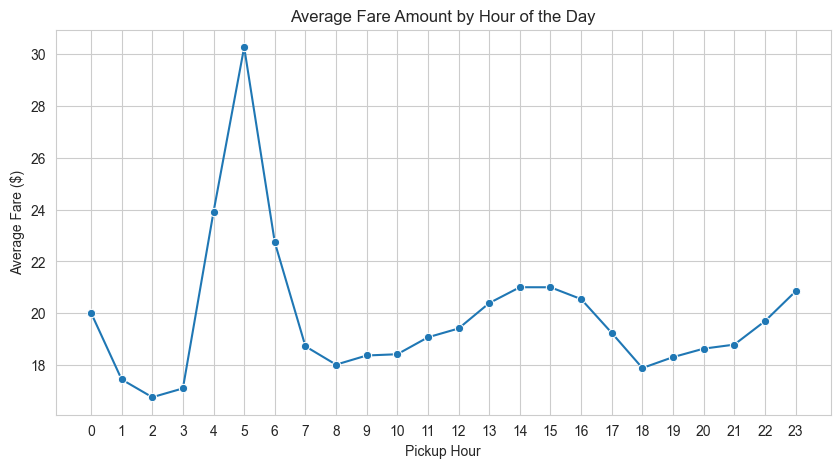

In [627]:
# Average Fare by Hour (for Dynamic Pricing)
plt.figure(figsize=(10, 5))
sns.lineplot(x='pickup_hour', y='fare_amount', data=merge_df, estimator='mean', ci=None, marker='o')
plt.title('Average Fare Amount by Hour of the Day')
plt.xlabel('Pickup Hour')
plt.ylabel('Average Fare ($)')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

C:\Users\harsh\AppData\Local\Temp\ipykernel_32380\1677513849.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Zone', y='Trip Count', data=zone_counts.head(10), palette='YlGnBu')


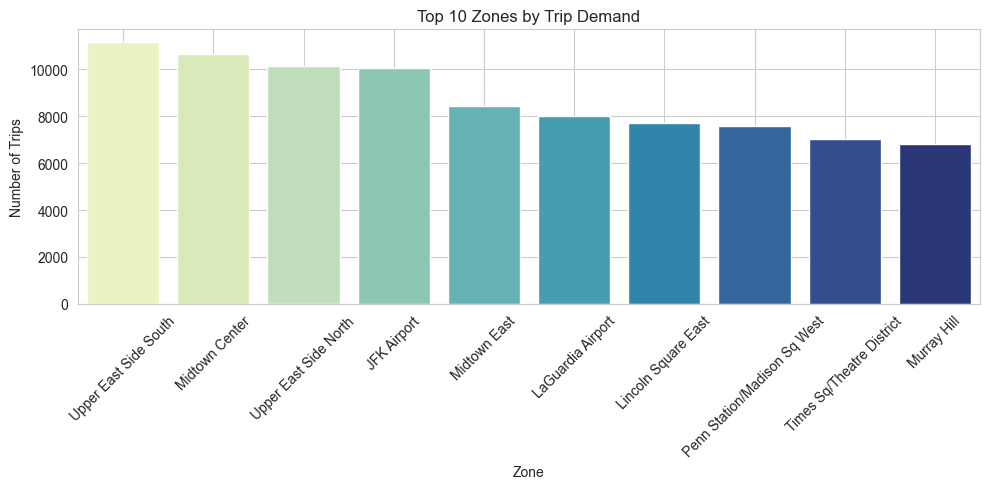

In [629]:
# Zone-Based Demand(for Zone-Based Pricing)
zone_counts = merge_df['zone'].value_counts().reset_index()
zone_counts.columns = ['Zone', 'Trip Count']
plt.figure(figsize=(10, 5))
sns.barplot(x='Zone', y='Trip Count', data=zone_counts.head(10), palette='YlGnBu')
plt.title('Top 10 Zones by Trip Demand')
plt.xticks(rotation=45)
plt.ylabel('Number of Trips')
plt.grid(True)
plt.tight_layout()
plt.show()

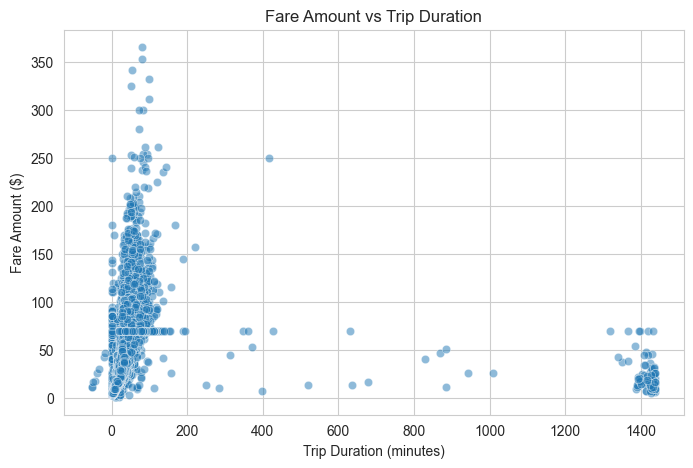

In [631]:
# Fare amount vs trip duration
plt.figure(figsize=(8, 5))
sns.scatterplot(x='trip_duration', y='fare_amount', data=merge_df, alpha=0.5)
plt.title('Fare Amount vs Trip Duration')
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Fare Amount ($)')
plt.grid(True)
plt.show()

C:\Users\harsh\AppData\Local\Temp\ipykernel_32380\3977956175.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='distance_tier', y='average_fare_per_mile', data=merge_df, palette='Set2')


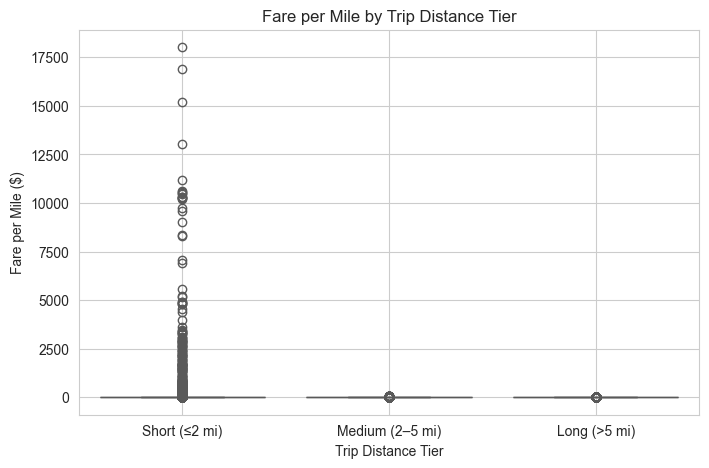

In [637]:
# Distance tiers
merge_df['distance_tier'] = pd.cut(merge_df['trip_distance'],
                                    bins=[0, 2, 5, merge_df['trip_distance'].max()],
                                    labels=['Short (≤2 mi)', 'Medium (2–5 mi)', 'Long (>5 mi)'])

plt.figure(figsize=(8, 5))
sns.boxplot(x='distance_tier', y='average_fare_per_mile', data=merge_df, palette='Set2')
plt.title('Fare per Mile by Trip Distance Tier')
plt.xlabel('Trip Distance Tier')
plt.ylabel('Fare per Mile ($)')
plt.grid(True)
plt.show()